### Лабораторная работа 3. Имитация систем непрерывных и дискретных случайных величин

In [1]:
%matplotlib notebook

import random
from typing import NamedTuple

import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits import mplot3d

import sympy as sp
import scipy
import math
from scipy.stats import norm, chi2
import scipy.stats as stats


from IPython.display import display as ipydisplay, Math

%matplotlib inline

In [2]:
USE_CUSTOM_RANDOM_FUNCTION = False

if USE_CUSTOM_RANDOM_FUNCTION:
    lcg_X = 42   # seed
    def lcg():
        global lcg_X
        a = 1103515245
        c = 12345
        m = 2**31
        lcg_X = ((a*lcg_X + c) % m) / m
        return lcg_X
    rand = lcg
else:
    rand = random.random

## Задание 1

Написать программу, реализующую метод формирования двумерной НСВ с определенным распределением.

Выполнить статистическое исследование:
1. Проверить составляющие двумерной НСВ на независимость;
2. Найти условные плотности распределения;
3. Построить гистограммы составляющих двумерной НСВ и графики их плотностей распределения в одной системе координат;
4. *Построить гистограмму распределения двумерной НСВ и график плотности распределения в одной системе координат (3D-график);
5. Вычислить теоретические, точечные и интервальные значения характеристик двумерной НСВ (математическое ожидание, дисперсия, корреляция);
6. *Проверить статистические гипотезы о соответствии полученных оценок характеристик (математическое ожидание, дисперсия, корреляция) случайной величины теоретическим.


По аналогии с одномерным случаем, для системы случайных величин тоже вводится понятие функции распределения вероятностей, она определяется как  – вероятность того, что случайная величина X примет значение мЕньшее, чем x и Y – мЕньшее, чем y, при этом переменные x, y «пробегают» все действительные значения от «минус» до «плюс» бесконечности. Откуда следует, что данная функция  удовлетворяет неравенству 0<=F(x, y)<=1, является неубывающей по каждому аргументу

Если же компоненты X, Y– непрерывны, то F(X, Y) непрерывна в любой точке плоскости XOY и её график представляет собой кусочно-гладкую или даже полностью гладкую поверхность

функция плотности распределения представляет собой смешанную производную 2-го порядка от функции распределения - f(x, y) = d^2(F(x, y)) / (dx dy)

In [3]:
# Исследуемый закон распределения:

# Плотность распределения:

f_str = '16/9 * (x + (y**3)/4)'
f_sp = sp.sympify(f_str)
f = sp.lambdify(sp.symbols('x, y'), f_sp)
x_sp, y_sp = sp.symbols('x y')

ipydisplay(Math(f'f(x, y) = {f_sp}'))

<IPython.core.display.Math object>

In [4]:
# Специальный тип для функции плотности и задания границ:

class Pdf2dBundle(NamedTuple):
    pdf: callable
    x1: float
    x2: float
    y1: float
    y2: float

f_bundle = Pdf2dBundle(
    pdf=f,
    x1=0,
    x2=1,
    y1=0,
    y2=1,
)

In [5]:
# Функция распределения (CDF):

F_sp = sp.integrate(
    f_sp,
    (x_sp, f_bundle.x1, x_sp),
    (y_sp, f_bundle.y1, y_sp),
)
F = sp.lambdify(sp.symbols('x, y'), F_sp)

ipydisplay(Math(f'F(x, y) = {sp.latex(sp.simplify(F_sp))}'))

<IPython.core.display.Math object>

График функции плотности распределения называют поверхностью распределения, и в силу свойства  данная поверхность «висит» над координатной плоскостью .

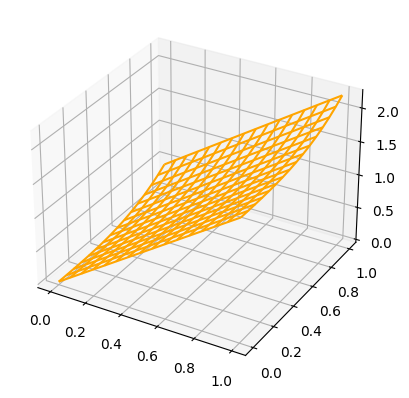

In [6]:
# 3D график плотности распределения

node_count = 16

x_list = np.linspace(
    f_bundle.x1,
    f_bundle.x2,
    node_count,
)
y_list = np.linspace(
    f_bundle.y1,
    f_bundle.y2,
    node_count,
)
X, Y = np.meshgrid(x_list, y_list)
Z = f(X, Y)

fig = plt.figure(label='Плотность распределения')
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='orange')

plt.show()

In [7]:
plt.clf()

<Figure size 640x480 with 0 Axes>

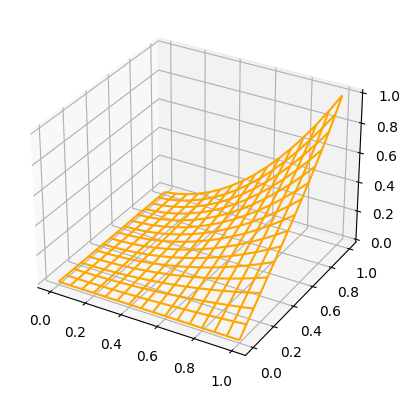

In [8]:
# 3D график функции распределения

Z = F(X, Y)

fig = plt.figure(label='Функция распределения')
ax = plt.axes(projection='3d')
ax.plot_wireframe(
    X, Y, Z,
    color='orange',
)

plt.show()

In [9]:
plt.clf()

<Figure size 640x480 with 0 Axes>

Настоящий порядок состоит в том, что несобственный интеграл от с пределами интегрирования от «минус» до «плюс» бесконечности: равен единице, и строго единице. 

В противном случае перед нами не функция плотности, и если эта функция найдена как производная, то  – не является функцией распределения (несмотря на какие бы то ни было другие признаки).

Если случайная величина  принимает значения из конечного промежутка, то всё дело сводится к вычислению определённого интеграла.

In [10]:
# Проверка, что значение определенного интеграла функции плотности распределения равно 1:

integral_value = sp.integrate(
    f_sp,
    (x_sp, f_bundle.x1, f_bundle.x2),
    (y_sp, f_bundle.y1, f_bundle.y2),
)

ipydisplay(Math(f'\\int_{{0}}^{{\\pi/2}} \\int_{{0}}^{{\\pi/2}} {f_str} \,dx dy = {round(float(integral_value), 2)}'))

<IPython.core.display.Math object>

### 1. Проверить составляющие двумерной НСВ на независимость

Если f(x, y) = f(x) * f(y), то X, Y независимы

In [11]:
# Одномерные плотности:

f_x_sp = sp.integrate(
    f_sp,
    (y_sp, f_bundle.x1, f_bundle.x2)
)
f_x = sp.lambdify(
    sp.symbols('x'),
    f_x_sp,
)

f_y_sp = sp.integrate(
    f_sp,
    (x_sp, f_bundle.y1, f_bundle.y2)
)
f_y = sp.lambdify(
    sp.symbols('y'),
    f_y_sp,
)

ipydisplay(Math(f'f(x) = {sp.latex(sp.simplify(f_x_sp))}'))
ipydisplay(Math(f'f(y) = {sp.latex(sp.simplify(f_y_sp))}'))

multiplied_sp = sp.Mul(f_x_sp, f_y_sp)
multiplied = sp.lambdify(sp.symbols('x, y'), multiplied_sp)
ipydisplay(Math(f'f(x)*f(y) = {sp.latex(sp.simplify(multiplied_sp))}'))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

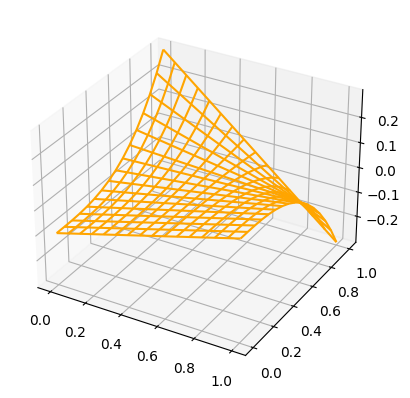

In [12]:
# График разности f(x, y) и f(x)*f(y):

Z = f(X, Y) - multiplied(X, Y)
fig = plt.figure(label='Разность f(x, y) и f(x)*f(y)')
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='orange')

plt.show()

### 2. Найти условные плотности распределения

Усло́вное распределе́ние в теории вероятностей — это распределение случайной величины при условии, что другая случайная величина принимает определённое значение.

In [13]:
f_x_pipe_y_sp = f_sp / f_y_sp
f_y_pipe_x_sp = f_sp / f_x_sp

ipydisplay(Math(f'f(x | y) = {sp.latex(sp.simplify(f_x_pipe_y_sp))}'))
ipydisplay(Math(f'f(y | x) = {sp.latex(sp.simplify(f_y_pipe_x_sp))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3. Построить гистограммы составляющих двумерной НСВ и графики их плотностей распределения в одной системе координат

In [14]:
# Функция для генерации выборки по функции плотности:

sample_size = 1_000_000

def generate_sample(pdf_bundle: Pdf2dBundle, sample_size=sample_size):
    sample = []
    while len(sample) < sample_size:
        x = pdf_bundle.x1 + rand() * (pdf_bundle.x2 - pdf_bundle.x1)
        y = pdf_bundle.y1 + rand() * (pdf_bundle.y2 - pdf_bundle.y1)
        z = rand()
        if z < pdf_bundle.pdf(x, y):
            sample.append((x, y))
    return sample

In [15]:
# Построение выборки:

sample = generate_sample(f_bundle)
x_sample = [el[0] for el in sample]
y_sample = [el[1] for el in sample]

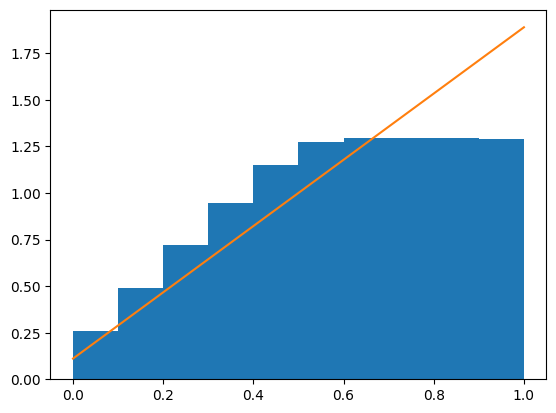

In [16]:
# Построение гистограммы для иксов:

fig = plt.figure(label='Гистограмма 1')

plt.hist(
    x_sample,
    density=True,
    bins=10,
)
plt.plot(
    x_list,
    f_x(x_list),
)
plt.show()

In [17]:
plt.clf()

<Figure size 640x480 with 0 Axes>

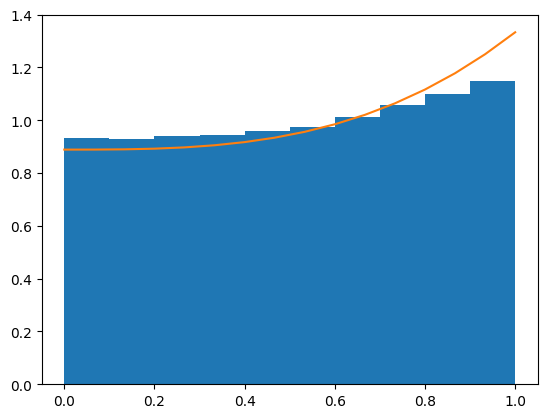

In [18]:
# Построение гистограммы для игреков:

fig = plt.figure(label='Гистограмма 2')

plt.hist(
    y_sample,
    density=True,
    bins=10,
)
plt.plot(
    y_list,
    f_y(y_list),
)
plt.show()

### 5. Вычислить теоретические, точечные и интервальные значения характеристик двумерной НСВ

- \+ математическое ожидание
- \+ дисперсия
- \+ среднеквадратическое отклонение
- \+ коэффициент корреляции
- \+ доверительные интервалы для математического ожидания
- \+ доверительные интервалы для дисперсии

In [19]:
# Ожидаемое и наблюдаемое математическое ожидание:

expected_mean = (
    scipy.integrate.dblquad(
        lambda x, y: x * f(x, y),
        f_bundle.x1, f_bundle.x2,
        f_bundle.y1, f_bundle.y2
    )[0],
    scipy.integrate.dblquad(
        lambda x, y: y * f(x, y),
        f_bundle.x1, f_bundle.x2,
        f_bundle.y1, f_bundle.y2
    )[0]
)
observed_mean = (
    np.mean(x_sample),
    np.mean(y_sample),
)

print(f'expected mean: {expected_mean}')
print(f'observed mean: {observed_mean}')

expected mean: (0.648148148148148, 0.5333333333333333)
observed mean: (0.5957861710943331, 0.520124784087755)


In [20]:
# Ожидаемая и наблюдаемая дисперсия:

expected_variance = (
    scipy.integrate.dblquad(
        lambda x, y: (x - expected_mean[0])**2 * f(x, y),
        f_bundle.x1, f_bundle.x2,
        f_bundle.y1, f_bundle.y2,
    )[0],
    scipy.integrate.dblquad(
        lambda x, y: (y - expected_mean[1])**2 * f(x, y),
        f_bundle.x1, f_bundle.x2,
        f_bundle.y1, f_bundle.y2,
    )[0],
)

observed_variance = (
    np.var(x_sample),
    np.var(y_sample),
)

print(f'expected variance: {expected_variance}')
print(f'observed variance: {observed_variance}')

print(f'expected standard deviation: {expected_variance[0]**0.5, expected_variance[1]**0.5}')
print(f'observed standard deviation: {observed_variance[0]**0.5, observed_variance[1]**0.5}')

expected variance: (0.061385459533607675, 0.08592592592592593)
observed variance: (0.06260662892928724, 0.08490054211717603)
expected standard deviation: (0.2477608918566602, 0.293131243517176)
observed standard deviation: (0.25021316697825324, 0.29137697595585005)


Для устранения недостатка ковариации был введён линейный коэффициент корреляции (или коэффициент корреляции Пирсона), который разработали Карл Пирсон, Фрэнсис Эджуорт и Рафаэль Уэлдон в 90-х годах XIX века. Коэффициент корреляции рассчитывается по формуле:

r(x, y) = cov(x, y) / (sqrt(D(x)) * sqrt(D(y))) = sum ((X - mean(X) * (Y - mean(Y)))) / sqrt(sum(X - mean(X))^2 * sum(Y - mean(Y))^2)

In [21]:
# Ожидаемая и наблюдаемая корреляция:

expected_r_xy = scipy.integrate.dblquad(
    lambda x, y: ((x - expected_mean[0]) *
                  (y - expected_mean[1]) *
                  f(x, y)),
    f_bundle.x1, f_bundle.x2,
    f_bundle.y1, f_bundle.y2,
)[0] / np.sqrt(expected_variance[0] * expected_variance[1])

x_sample_centered = x_sample - observed_mean[0]
y_sample_centered = y_sample - observed_mean[1]

observed_r_xy = ((x_sample_centered @ y_sample_centered)
                 / (len(x_sample)
                    * np.sqrt(observed_variance[0]
                              * observed_variance[1])))

print(f'expected r_xy: {expected_r_xy}')
print(f'observed r_xy: {observed_r_xy}')

expected r_xy: -0.06799548978209506
observed r_xy: -0.09922782346877167


In [22]:
gamma = 0.95 # уровень доверия
hypothesis_error_value = 0.05

# confidence interval
def get_delta(offset):
    t = norm.ppf(gamma / 2 + 0.5) # квантили
    return t * offset / np.sqrt(sample_size) # Margin of Error

def get_offset_delta(test_offset): # build confidence level (хи квадрат)
    alphas = ((1 - gamma) / 2, (1 + gamma) / 2)
    chis = (chi2.isf(alphas, sample_size - 1))
    temp = np.sqrt(sample_size - 1) * test_offset
    
    return (temp / np.sqrt(chis[0]), temp / np.sqrt(chis[1]))

In [23]:
theoretical_std_deviation_x = expected_variance[0]**0.5
theoretical_std_deviation_y = expected_variance[1]**0.5

sample_std_deviation_x = observed_variance[0]**0.5
sample_std_deviation_y = observed_variance[1]**0.5

delta_x = get_delta(theoretical_std_deviation_x)
delta_y = get_delta(theoretical_std_deviation_y)
offset_delta_x = get_offset_delta(sample_std_deviation_x)
offset_delta_y = get_offset_delta(sample_std_deviation_y)

val_x = np.square(offset_delta_x)
val_y = np.square(offset_delta_y)

print(f'confidence interval x for mean: {observed_mean[0]-delta_x, observed_mean[0]+delta_x}')
print(f'confidence interval y for mean: {observed_mean[1]-delta_y, observed_mean[1]+delta_y}')

print(f'confidence interval x for variance: {val_x}')
print(f'confidence interval y for variance: {val_y}')

confidence interval x for mean: (0.5953005686695165, 0.5962717735191496)
confidence interval y for mean: (0.5195502574077179, 0.5206993107677921)
confidence interval x for variance: [0.06243346 0.06278053]
confidence interval y for variance: [0.0846657  0.08513636]


## Задание 2

Написать программу, реализующую метод формирования двумерной ДСВ. Матрицу распределения ДСВ задаете самостоятельно.

Выполнить статистическое исследование:
1. Проверить составляющие двумерной ДСВ на независимость;
2. Найти условные плотности распределения;
3. Построить гистограммы составляющих двумерной ДСВ;
4. *Построить гистограмму распределения двумерной ДСВ (3D-график);
5. Вычислить теоретические, точечные и интервальные значения характеристик двумерной ДСВ (математическое ожидание, дисперсия, корреляция);
6. *Проверить статистические гипотезы о соответствии полученных оценок характеристик (математическое ожидание, дисперсия, корреляция) случайной величины теоретическим.

В случае двух величин (скажем, X и Y) мы имеем дело с так называемой двумерной дискретной случайной величиной (X,Y)(или системой случайных одномерных величин).

Интегральная функция распределения задается формулой F(x,y)=P(X<x,Y<y).

Если для любой пары возможных значений (X=xi,Y=yk) выполняется равенство
P(X=xi,Y=yk) = P(X=xi)⋅ P(Y=yk),
то случайные величины X,Y называются независимыми.

Если случайные величины зависимы, для них можно выписать условные законы распределения (для независимых они совпадают с безусловными законами):

P(X=xi|Y=yk)=P(X=xi,Y=yk) / P(Y=yk),
P(Y=yk|X=xi)=P(X=xi,Y=yk) / P(X=xi).

In [24]:
X = [1, 2, 3, 4, 5]
Y = [10, 20, 30, 40, 50]
P = [
        [0, 0, 0.05, 0.05, 0.1],
        [0.025, 0.025, 0.025, 0.025, 0.04],
        [0.05, 0.025, 0, 0, 0.1],
        [0.11, 0.07, 0.03, 0.05, 0.055],
        [0.070, 0.05, 0.05, 0, 0]
]

# Вычисление маргинальных распределений
p_x = [sum(row) for row in P]
p_y = [sum(y) for y in zip(*P)]

# Вычисление условных плотностей распределения
p_yi = [[y / p_x[i] for y in row] for i, row in enumerate(P)]

# Считаем кумулятивную сумму (значения функции распределения)
F_x = np.cumsum(p_x)
F_y = [np.cumsum(p_yi[i]) for i in range(len(Y))]

In [25]:
def get_var_and_index(x, F_x, p):
    '''
    Проходит по списку кумулятивных сумм F_x и 
    находит первый элемент, который больше или равен заданной вероятности p.
    Возвращает значение случайной величины (X или Y) 
    и индекс этого значения в списке.
    '''
    return next((x[i], i) for i, p_ in enumerate(F_x) if p_ >= p)

n = 10000

x_l, y_l = [], []
for _ in range(n):
    x, i = get_var_and_index(X, F_x, rand())
    x_l.append(x)
    y_l.append(get_var_and_index(Y, F_y[i], rand())[0])
    
p_x_imp = [x_l.count(X[i]) / n for i in range(len(X))]
p_y_imp = [y_l.count(Y[i]) / n for i in range(len(Y))]

In [26]:
r_theo = lambda M_xy, M_x, M_y, D_x, D_y: (M_xy - M_x * M_y) / math.sqrt(D_x * D_y)


M_f = lambda v, p_v: sum([v[i] * p_v[i] for i in range(len(v))])

def D_f(v, p_v, M=None):
    if M is None:
        M = M_f(v, p_v)
    return sum([(v[i] ** 2) * p_v[i] for i in range(len(v))]) - M ** 2

M_x = M_f(X, p_x)
M_y = M_f(Y, p_y)
M_xy = sum([
    sum([x * y * P[i][j] for j, y in enumerate(Y)])
    for i, x in enumerate(X)
])
D_x = D_f(X, p_x, M_x)
D_y = D_f(Y, p_y, M_y)

print('Теоретические характеристики')
print('M[x] =', M_x, 'D[x] =', D_x)
print('M[y] =', M_y, 'D[y] =', D_y)
print('r[xy] =', r_theo(M_xy, M_x, M_y, D_x, D_y))
print()
print('Эмпирические характеристики')
print('M[x] =', M_f(X, p_x_imp), 'D[x] =', D_f(X, p_x_imp))
print('M[y] =', M_f(Y, p_y_imp), 'D[y] =', D_f(Y, p_y_imp))
print('r =', stats.pearsonr(x_l, y_l)[0])


Теоретические характеристики
M[x] = 3.115 D[x] = 1.9217749999999985
M[y] = 30.35 D[y] = 249.37749999999994
r[xy] = -0.47690403306892665

Эмпирические характеристики
M[x] = 3.1289 D[x] = 1.904284790000002
M[y] = 30.328000000000003 D[y] = 248.81241599999976
r = -0.47306467015697584


In [27]:
def draw_plot(v, p_v, p_v_imp, var_name):
    plt.plot(v, p_v, label='theoretical', color='gray', alpha=0.5, ls='--')
    plt.plot(v, p_v_imp, label=f'imperical', color='r', alpha=0.5)
    plt.title(f'{var_name} histogram')
    plt.legend()
    plt.show()

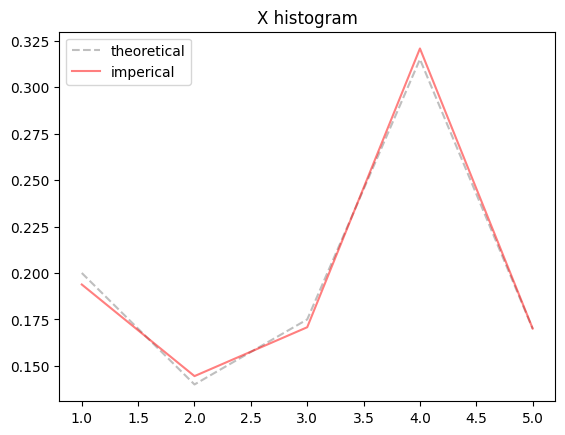

In [28]:
draw_plot(X, p_x, p_x_imp, 'X')

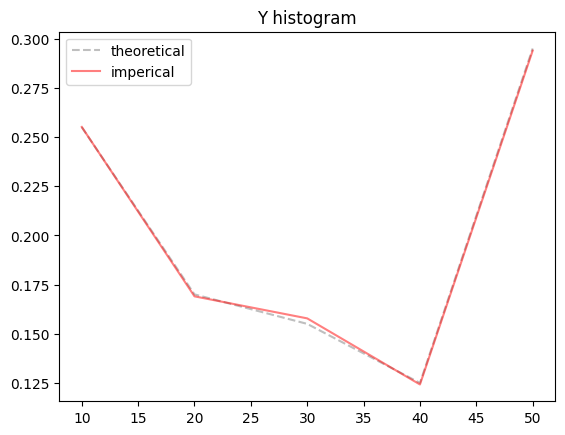

In [29]:
draw_plot(Y, p_y, p_y_imp, 'Y')

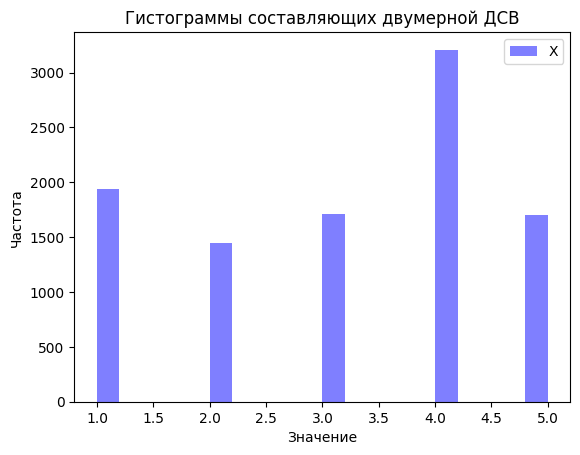

In [30]:
plt.hist(x_l, bins=20, alpha=0.5, color='b', label='X')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()
plt.title('Гистограммы составляющих двумерной ДСВ')
plt.show()

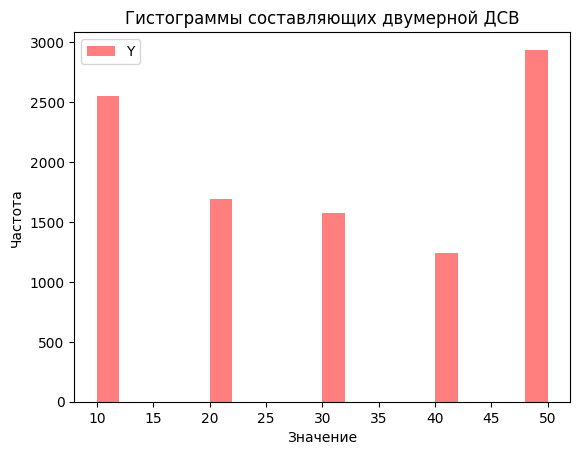

In [31]:
plt.hist(y_l, bins=20, alpha=0.5, color='r', label='Y')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()
plt.title('Гистограммы составляющих двумерной ДСВ')
plt.show()